In [4]:
# ==========================================
# STEP 1: LOAD & AUGMENT YOUR PROJECT DATA
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Load your actual 15-row CSV file
try:
    df_original = pd.read_csv('sprint_delivery_data.csv')
    print("✅ Original sprint_delivery_data.csv loaded successfully!")
except FileNotFoundError:
    print("❌ Error: Please upload 'sprint_delivery_data.csv' to Colab first.")

# 2. Data Augmentation (Expanding 15 rows to 100 for robust analysis/ML)
np.random.seed(42)
n_records = 100

# Extract unique categories directly from YOUR actual CSV
teams = df_original['Team'].unique()
developers = df_original['Assigned_Developer'].unique()
statuses = df_original['Status'].unique()
story_points = df_original['Story_Points'].unique()

# Generate expanded dataset based on your CSV's distributions
data = {
    'Task_ID': [f'TSK-{100+i}' for i in range(n_records)],
    'Team': np.random.choice(teams, n_records),
    'Assigned_Developer': np.random.choice(developers, n_records),
    'Story_Points': np.random.choice(story_points, n_records),
    'Days_In_Sprint': np.random.randint(1, 14, n_records)
}
df = pd.DataFrame(data)

# Inject logical rules matching your CSV's patterns
status_list = []
blocker_list = []
for idx, row in df.iterrows():
    if row['Story_Points'] >= 5 and np.random.rand() > 0.4:
        status_list.append('Blocked')
        blocker_list.append('Awaiting API credentials' if row['Team'] == 'Backend' else 'Figma design update pending')
    elif row['Days_In_Sprint'] > 9 and np.random.rand() > 0.5:
        status_list.append('In Progress')
        blocker_list.append('None')
    else:
        status_list.append('Completed' if np.random.rand() > 0.3 else 'To Do')
        blocker_list.append('Completed successfully')

df['Status'] = status_list
df['Blocker_Reason'] = blocker_list

# Define target variable: "Spillover_Risk" (1 if Blocked/In Progress with high days, 0 otherwise)
df['Spillover_Risk'] = np.where((df['Status'].isin(['Blocked', 'In Progress'])) & (df['Days_In_Sprint'] > 6), 1, 0)

print(f"📈 Dataset successfully expanded to {len(df)} rows for analysis. Preview:")
df.head()

✅ Original sprint_delivery_data.csv loaded successfully!
📈 Dataset successfully expanded to 100 rows for analysis. Preview:


,Task_ID,Team,Assigned_Developer,Story_Points,Days_In_Sprint,Status,Blocker_Reason,Spillover_Risk
0,TSK-100,QA,Nina Osei,5,8,Completed,Completed successfully,0
1,TSK-101,DevOps,Raj Patel,2,11,In Progress,None,1
2,TSK-102,Frontend,Raj Patel,5,1,Blocked,Figma design update pending,0
3,TSK-103,QA,Tom Becker,2,6,To Do,Completed successfully,0
4,TSK-104,QA,Raj Patel,3,8,Completed,Completed successfully,0


In [5]:
# ==========================================
# STEP 2: SPRINT METRICS & KPI CALCULATIONS
# ==========================================
total_tasks = len(df)
completed_tasks = len(df[df['Status'] == 'Completed'])
completion_rate = (completed_tasks / total_tasks) * 100
total_points = df['Story_Points'].sum()
completed_points = df[df['Status'] == 'Completed']['Story_Points'].sum()

print("=========================================")
print("        AGILE SPRINT PERFORMANCE         ")
print("=========================================")
print(f"Total Backlog Tasks    : {total_tasks}")
print(f"Sprint Completion Rate : {completion_rate:.1f}%")
print(f"Total Committed Points : {total_points} SP")
print(f"Total Delivered Points : {completed_points} SP")
print(f"Velocity Achievement   : {(completed_points / total_points)*100:.1f}%")
print("=========================================")

        AGILE SPRINT PERFORMANCE         
Total Backlog Tasks    : 100
Sprint Completion Rate : 49.0%
Total Committed Points : 452 SP
Total Delivered Points : 184 SP
Velocity Achievement   : 40.7%


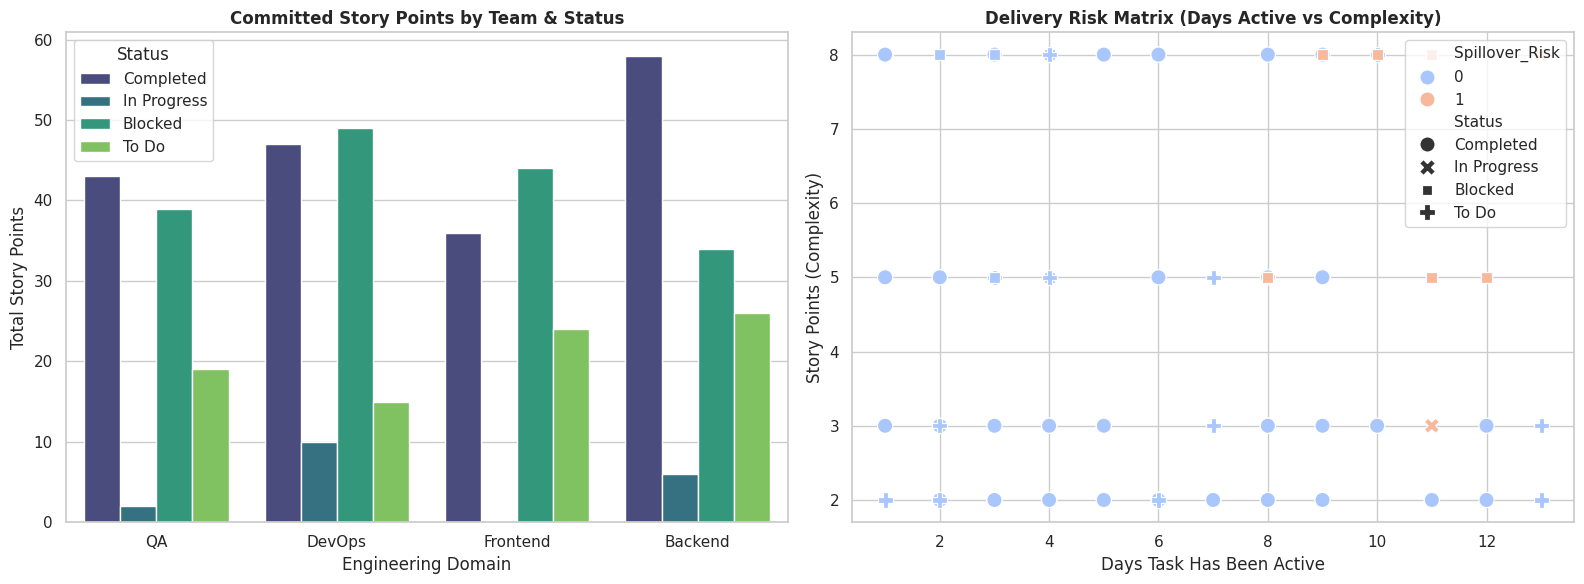

In [6]:
# ==========================================
# STEP 3: VISUALIZING BOTTLENECK DOMAINS
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Story points by team and status
sns.barplot(ax=axes[0], data=df, x='Team', y='Story_Points', hue='Status', estimator=sum, errorbar=None, palette='viridis')
axes[0].set_title('Committed Story Points by Team & Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Story Points')
axes[0].set_xlabel('Engineering Domain')

# Chart 2: Days in sprint vs Story points (Scatter)
sns.scatterplot(ax=axes[1], data=df, x='Days_In_Sprint', y='Story_Points', hue='Spillover_Risk', style='Status', s=120, palette='coolwarm')
axes[1].set_title('Delivery Risk Matrix (Days Active vs Complexity)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Days Task Has Been Active')
axes[1].set_ylabel('Story Points (Complexity)')

plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# STEP 4: PREDICTIVE MODELLING (SPILLOVER RISK)
# ==========================================
# Encode categories to numeric values
df_ml = df.copy()
le_team = LabelEncoder()
le_dev = LabelEncoder()

df_ml['Team_Encoded'] = le_team.fit_transform(df_ml['Team'])
df_ml['Dev_Encoded'] = le_dev.fit_transform(df_ml['Assigned_Developer'])

# Define features (X) and target (y)
X = df_ml[['Team_Encoded', 'Dev_Encoded', 'Story_Points', 'Days_In_Sprint']]
y = df_ml['Spillover_Risk']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print("--- MODEL CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

# Feature Importance to show what drives delays
importances = model.feature_importances_
for name, importance in zip(X.columns, importances):
    print(f"Feature: {name:15} | Impact Score: {importance:.4f}")

--- MODEL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        16
           1       0.40      0.50      0.44         4

    accuracy                           0.75        20
   macro avg       0.63      0.66      0.64        20
weighted avg       0.77      0.75      0.76        20

Feature: Team_Encoded    | Impact Score: 0.1230
Feature: Dev_Encoded     | Impact Score: 0.1734
Feature: Story_Points    | Impact Score: 0.2021
Feature: Days_In_Sprint  | Impact Score: 0.5015
